In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

output = "output/"
time_points = [0, 15, 30, 45, 60]  # adjust these based on your data

## Exercise 1.1 — Single Plasmid (BFP) Histograms

In [2]:
df1 = pd.read_csv(output + "constitutive_transfect_1_plasmid.csv", skipinitialspace=True)
df1.columns = df1.columns.str.strip().str.rstrip(',')
df1 = df1.rename(columns=lambda c: c.strip().rstrip(','))
df1.head()

,cell id,time,volume,plasmid_bfp,bfp,Unnamed: 5
0,0,0.02,1.57012,188.72,0,NaN
1,1,0.02,1.57002,188.72,0,NaN
2,2,0.02,1.57000,190.38,0,NaN
3,3,0.02,1.57003,199.66,0,NaN
4,4,0.02,1.57005,203.87,0,NaN


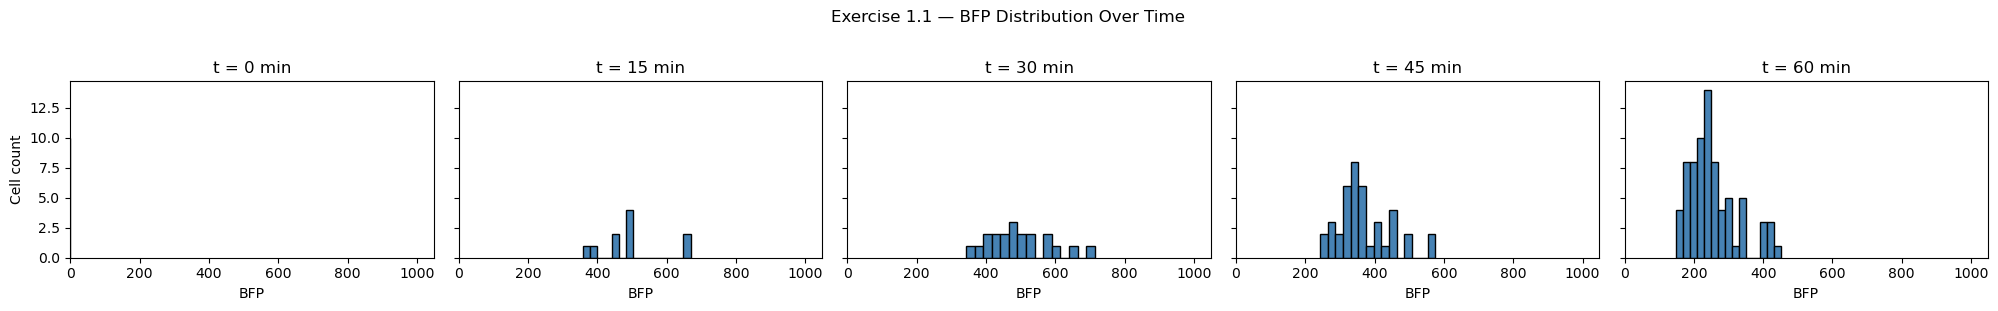

In [3]:
fig, axes = plt.subplots(1, len(time_points), figsize=(4 * len(time_points), 3), sharey=True)
bfp_max = df1[' bfp'].max() if ' bfp' in df1.columns else df1['bfp'].max()
bfp_col = ' bfp' if ' bfp' in df1.columns else 'bfp'
time_col = ' time' if ' time' in df1.columns else 'time'

for ax, tp in zip(axes, time_points):
    nearest = df1[time_col].unique()
    t = nearest[np.argmin(np.abs(nearest - tp))]
    subset = df1[df1[time_col] == t]
    ax.hist(subset[bfp_col], bins=15, color='steelblue', edgecolor='black')
    ax.set_title(f't = {t:.0f} min')
    ax.set_xlabel('BFP')
    ax.set_xlim(0, bfp_max * 1.1)
axes[0].set_ylabel('Cell count')
fig.suptitle('Exercise 1.1 — BFP Distribution Over Time', y=1.02)
plt.tight_layout()
plt.savefig(output + 'ex1_1_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## Exercise 1.2 — Three Plasmids, Three Complexes (Independent)

In [4]:
df3 = pd.read_csv(output + "constitutive_transfect_3_plasmids_3_complexes.csv", skipinitialspace=True)
df3.columns = df3.columns.str.strip().str.rstrip(',')
df3.head()

,cell id,time,volume,plasmid_bfp,plasmid_yfp,plasmid_rfp,bfp,yfp,rfp,Unnamed: 9
0,0,0.02,1.57012,201.630,191.130,255.870,0,0,0,NaN
1,1,0.02,1.57003,227.625,276.630,161.515,0,0,0,NaN
2,2,0.02,1.57008,190.380,204.295,244.430,0,0,0,NaN
3,3,0.02,1.57016,277.210,128.880,161.515,0,0,0,NaN
4,4,0.02,1.57003,199.660,146.920,244.430,1,0,0,NaN


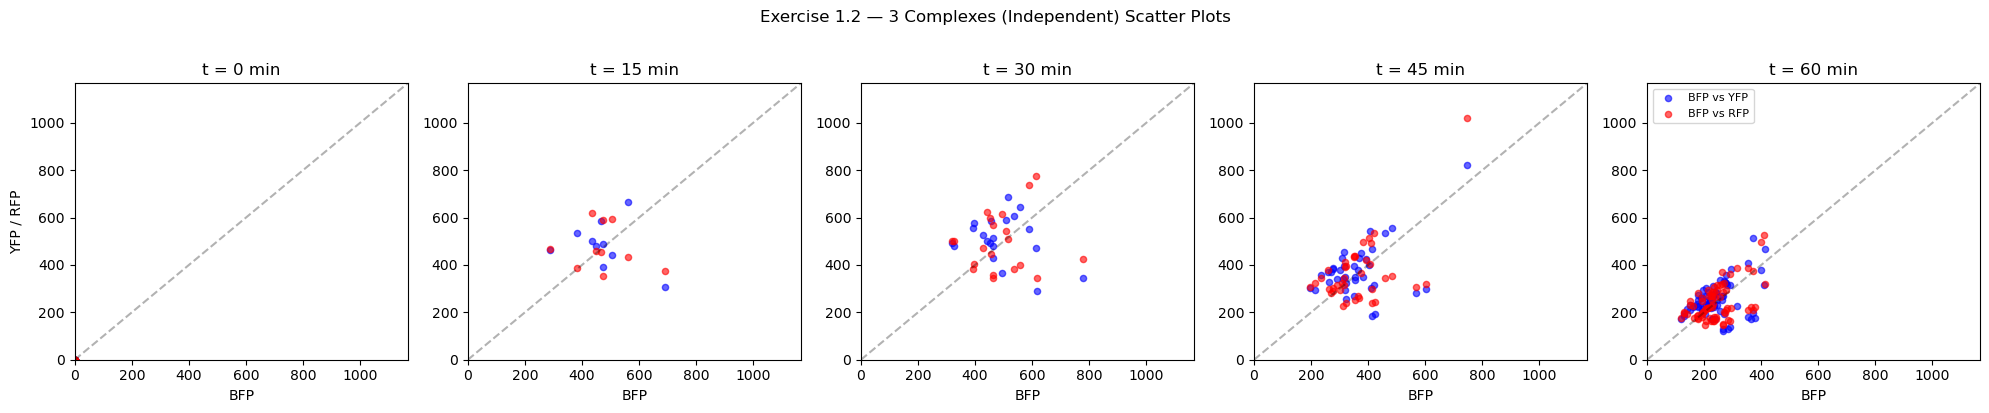

In [5]:
fig, axes = plt.subplots(1, len(time_points), figsize=(4 * len(time_points), 4))

all_bfp = df3['bfp']; all_yfp = df3['yfp']; all_rfp = df3['rfp']
lim = max(all_bfp.max(), all_yfp.max(), all_rfp.max()) * 1.1

for ax, tp in zip(axes, time_points):
    nearest = df3['time'].unique()
    t = nearest[np.argmin(np.abs(nearest - tp))]
    s = df3[df3['time'] == t]
    ax.scatter(s['bfp'], s['yfp'], c='blue', alpha=0.6, label='BFP vs YFP', s=20)
    ax.scatter(s['bfp'], s['rfp'], c='red', alpha=0.6, label='BFP vs RFP', s=20)
    ax.set_title(f't = {t:.0f} min')
    ax.set_xlabel('BFP')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.3)
axes[0].set_ylabel('YFP / RFP')
axes[-1].legend(fontsize=8)
fig.suptitle('Exercise 1.2 — 3 Complexes (Independent) Scatter Plots', y=1.02)
plt.tight_layout()
plt.savefig(output + 'ex1_2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Exercise 1.3 — Three Plasmids, One Complex (Correlated)

In [6]:
df1c = pd.read_csv(output + "constitutive_transfect_3_plasmids_1_complex.csv", skipinitialspace=True)
df1c.columns = df1c.columns.str.strip().str.rstrip(',')
df1c.head()

,cell id,time,volume,plasmid_bfp,plasmid_yfp,plasmid_rfp,bfp,yfp,rfp,Unnamed: 9
0,0,0.02,1.57005,129.885,129.885,129.885,0,0,0,NaN
1,1,0.02,1.57004,244.430,244.430,244.430,0,0,0,NaN
2,2,0.02,1.57005,276.630,276.630,276.630,0,0,0,NaN
3,3,0.02,1.57010,224.410,224.410,224.410,0,0,0,NaN
4,4,0.02,1.57005,199.660,199.660,199.660,0,0,0,NaN


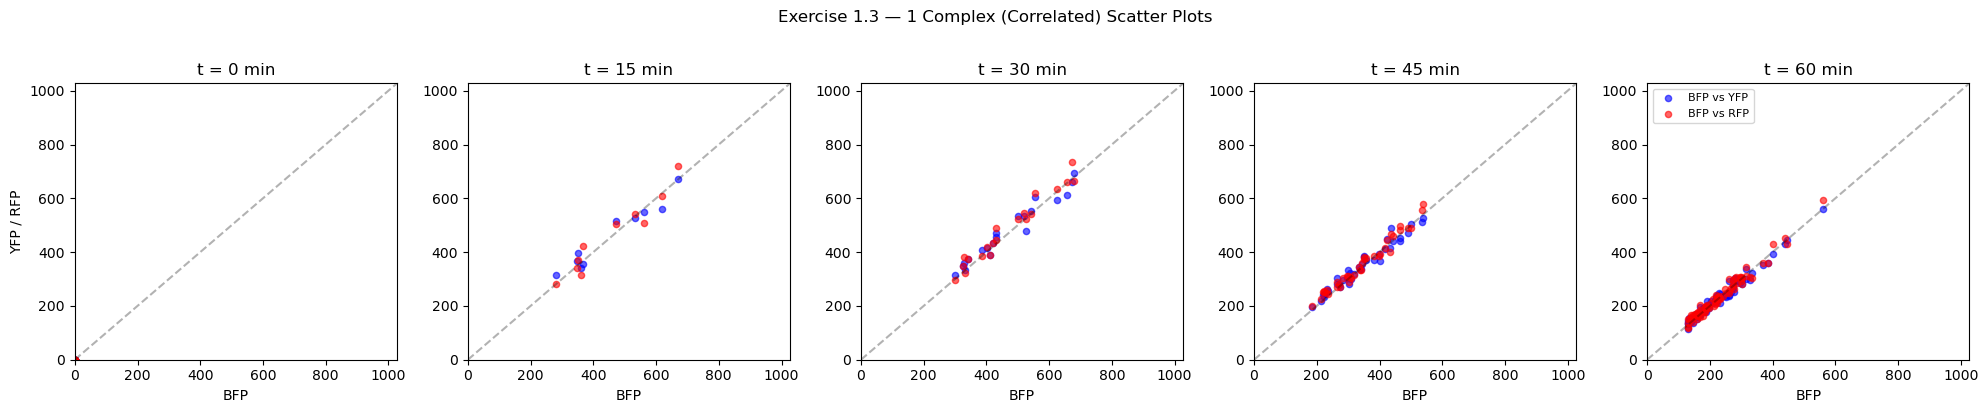

In [7]:
fig, axes = plt.subplots(1, len(time_points), figsize=(4 * len(time_points), 4))

all_bfp = df1c['bfp']; all_yfp = df1c['yfp']; all_rfp = df1c['rfp']
lim = max(all_bfp.max(), all_yfp.max(), all_rfp.max()) * 1.1

for ax, tp in zip(axes, time_points):
    nearest = df1c['time'].unique()
    t = nearest[np.argmin(np.abs(nearest - tp))]
    s = df1c[df1c['time'] == t]
    ax.scatter(s['bfp'], s['yfp'], c='blue', alpha=0.6, label='BFP vs YFP', s=20)
    ax.scatter(s['bfp'], s['rfp'], c='red', alpha=0.6, label='BFP vs RFP', s=20)
    ax.set_title(f't = {t:.0f} min')
    ax.set_xlabel('BFP')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.3)
axes[0].set_ylabel('YFP / RFP')
axes[-1].legend(fontsize=8)
fig.suptitle('Exercise 1.3 — 1 Complex (Correlated) Scatter Plots', y=1.02)
plt.tight_layout()
plt.savefig(output + 'ex1_3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()